<a href="https://colab.research.google.com/github/hiraljoshi93/Machine_Learning/blob/main/RF_SURAT_PC1PC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# =============================================================================
# STEP 0: Setup — libraries and settings
# =============================================================================
# If you run this in Google Colab and the CSV is not in the folder, uncomment:
# from google.colab import files
# uploaded = files.upload()   # choose input_vadodara.csv when prompted

import warnings
warnings.filterwarnings("ignore")  # hide minor warnings so output is easier to read

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: popular machine-learning library in Python
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

sns.set_theme(style="whitegrid")  # nicer-looking plots

RANDOM_STATE = 42       # fixed seed so results repeat if you run again
CSV_FILENAME = "Surat_9_Para_CSV_PC1PC2.csv"
TARGET = "RF"           # column name of rainfall (what we predict)

# Predictor columns we trust for *future* rainfall (meteorology + season)

MET_FEATURES = ["ATE", "CC", "DTR", "MTE", "RCETO", "VP", "WDF"]
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("Libraries loaded. Ready to start.")

Libraries loaded. Ready to start.


In [15]:
# Read CSV file into a table called df
try:
    df = pd.read_csv(CSV_FILENAME)
    print(f"SUCCESS: Loaded '{CSV_FILENAME}'")
    print(f"  Rows (months): {df.shape[0]}")
    print(f"  Columns: {df.shape[1]}")
except FileNotFoundError:
    raise FileNotFoundError(
        f"File '{CSV_FILENAME}' not found. "
        "Upload it in Colab (uncomment upload lines in Step 0) or place it next to this notebook."
    )

# Show first 5 rows — quick sanity check (years, months, numbers look reasonable?)
display(df.head())

SUCCESS: Loaded 'Surat_9_Para_CSV_PC1PC2.csv'
  Rows (months): 1224
  Columns: 10


,Year,Month,RF,ATE,CC,DTR,MTE,RCETO,VP,WDF
0,1901,Jan,2.714,16.204,9.306,12.436,22.459,2.88,10.343,0.5237
1,1901,Feb,0.000,16.706,9.101,12.660,23.035,3.41,10.290,0.0000
2,1901,Mar,2.115,21.064,14.990,12.037,27.081,4.43,12.906,0.3737
3,1901,Apr,0.776,23.017,15.459,10.836,28.427,4.93,16.422,0.5643
4,1901,May,1.595,24.436,18.931,9.145,29.040,4.99,19.689,0.5395


In [16]:
# Data type of each column (number vs text)
print("Data types:")
print(df.dtypes)

print("\nMissing values per column (0 = good):")
missing = df.isna().sum()
print(missing)

print(f"\nTime span: {df['Year'].min()} to {df['Year'].max()} "
      f"({df['Year'].nunique()} years, {len(df)} monthly records)")

Data types:
Year       int64
Month     object
RF       float64
ATE      float64
CC       float64
DTR      float64
MTE      float64
RCETO    float64
VP       float64
WDF      float64
dtype: object

Missing values per column (0 = good):
Year     0
Month    0
RF       0
ATE      0
CC       0
DTR      0
MTE      0
RCETO    0
VP       0
WDF      0
dtype: int64

Time span: 1901 to 2002 (102 years, 1224 monthly records)


In [17]:
# describe() gives count, mean, std, min, quartiles, max
print("=== Rainfall (RF) summary ===")
display(df[TARGET].describe().to_frame("RF (mm)"))

print("\n=== All numeric columns (short view) ===")
display(df.describe().T.round(2))

=== Rainfall (RF) summary ===


,RF (mm)
count,1224.000000
mean,93.973687
std,159.214278
min,0.000000
25%,0.021000
50%,2.131500
75%,144.616000
max,968.976000



=== All numeric columns (short view) ===


,count,mean,std,min,25%,50%,75%,max
Year,1224.0,1951.50,29.46,1901.00,1926.00,1951.50,1977.00,2002.00
RF,1224.0,93.97,159.21,0.00,0.02,2.13,144.62,968.98
ATE,1224.0,20.83,2.25,15.43,18.90,21.17,22.40,25.41
CC,1224.0,25.32,18.34,1.64,10.73,16.23,41.18,67.48
DTR,1224.0,9.46,2.80,4.63,6.77,10.34,12.03,12.93
MTE,1224.0,25.58,1.93,21.68,23.94,25.05,27.09,29.99
RCETO,1224.0,3.76,0.70,2.71,3.24,3.52,4.32,5.11
VP,1224.0,16.58,4.97,9.70,11.88,14.92,22.11,25.42
WDF,1224.0,3.39,4.77,0.00,0.02,0.65,6.38,19.54


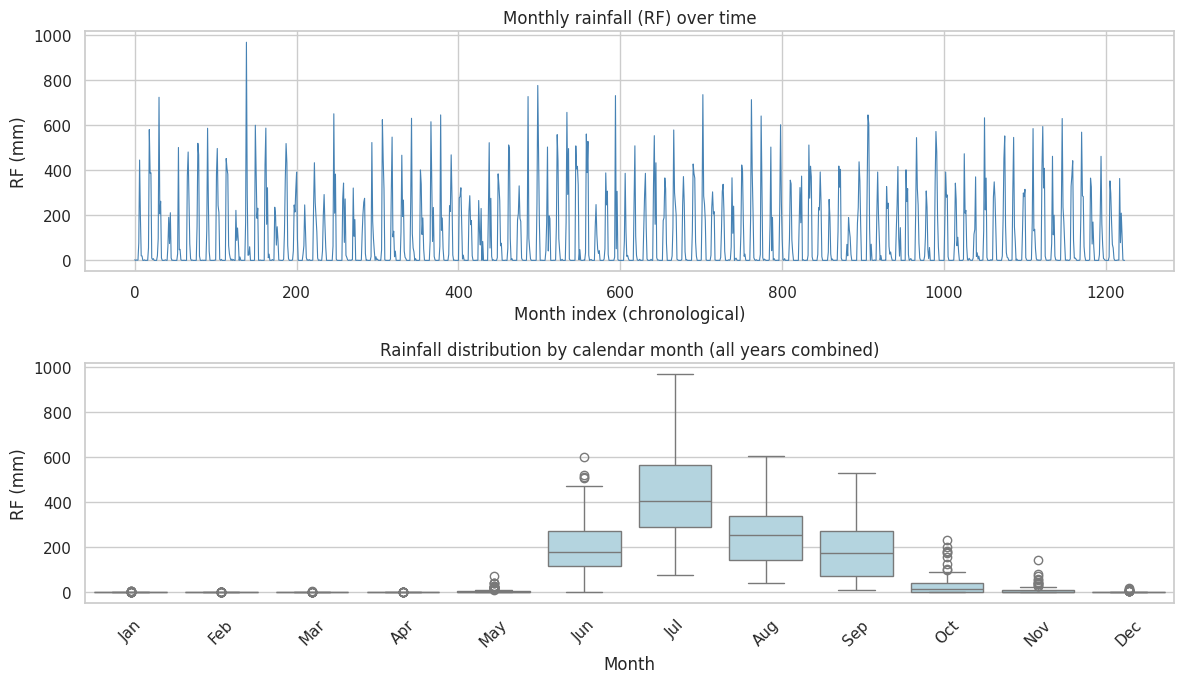

In [18]:
# Build a simple date order for plotting
df_eda = df.copy()
df_eda["month_num"] = df_eda["Month"].map({m: i + 1 for i, m in enumerate(MONTH_ORDER)})
df_eda = df_eda.sort_values(["Year", "month_num"]).reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Plot 1: RF over entire period (line chart)
axes[0].plot(df_eda.index, df_eda[TARGET], linewidth=0.8, color="steelblue")
axes[0].set_title("Monthly rainfall (RF) over time")
axes[0].set_xlabel("Month index (chronological)")
axes[0].set_ylabel("RF (mm)")

# Plot 2: Boxplot by calendar month — shows typical monsoon season
sns.boxplot(data=df_eda, x="Month", y=TARGET, order=MONTH_ORDER, ax=axes[1], color="lightblue")
axes[1].set_title("Rainfall distribution by calendar month (all years combined)")
axes[1].set_ylabel("RF (mm)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Correlation of each column with RF (sorted):


,Correlation with RF
WDF,0.940078
CC,0.815328
VP,0.686037
ATE,0.212285
month_num,0.169345
Year,0.006717
RCETO,-0.163537
MTE,-0.310173
DTR,-0.767327


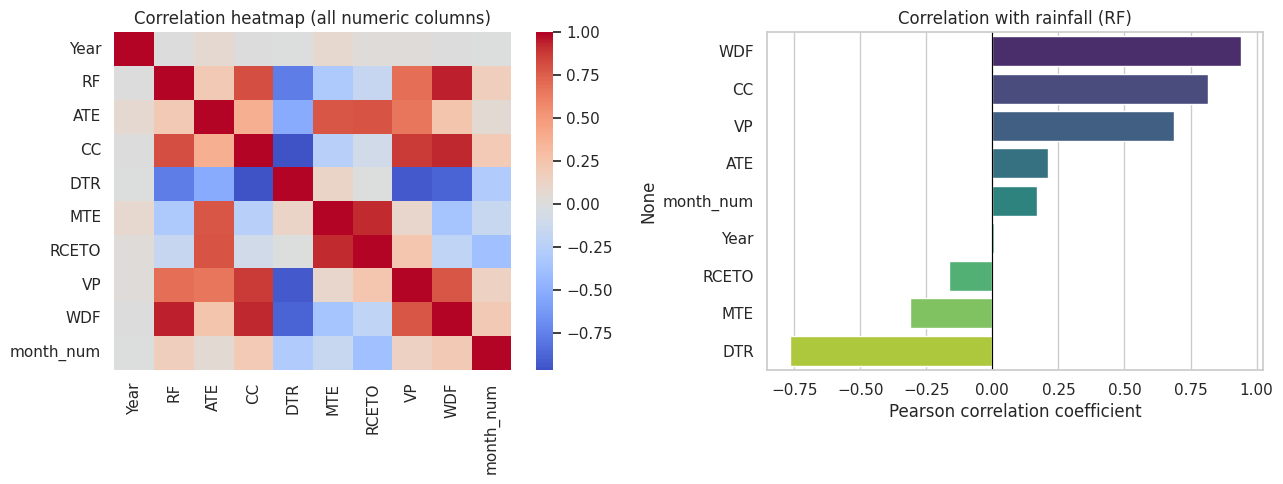

In [19]:
# Pearson correlation: +1 = increase together, -1 = one up other down, 0 = weak linear link
numeric_df = df_eda.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
corr_rf = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlation of each column with RF (sorted):")
display(corr_rf.to_frame("Correlation with RF"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Correlation heatmap (all numeric columns)")

sns.barplot(x=corr_rf.values, y=corr_rf.index, ax=axes[1], palette="viridis")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with rainfall (RF)")
axes[1].set_xlabel("Pearson correlation coefficient")
plt.tight_layout()
plt.show()


In [21]:
model_df = df_eda.copy() # Assuming model_df is based on df_eda
FEATURES = MET_FEATURES + ["Year", "month_num"]

TEST_FRACTION = 0.20  # 20% newest months go to test set
split_idx = int(len(model_df) * (1 - TEST_FRACTION))

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("TRAIN period:", train_df["Year"].min(), "–", train_df["Year"].max(),
      f"({len(train_df)} months)")
print("TEST period: ", test_df["Year"].min(), "–", test_df["Year"].max(),
      f"({len(test_df)} months)")
print("\nTrain RF mean (mm):", round(y_train.mean(), 2))
print("Test RF mean (mm): ", round(y_test.mean(), 2))

TRAIN period: 1901 – 1982 (979 months)
TEST period:  1982 – 2002 (245 months)

Train RF mean (mm): 93.76
Test RF mean (mm):  94.82


Training and evaluating each algorithm on the SAME train/test split...

=== MODEL COMPARISON (sorted best → worst by Test RMSE) ===


,Train_R2,Test_R2,Train_RMSE_mm,Test_RMSE_mm,Test_MAE_mm,Rank_by_Test_RMSE
Algorithm,,,,,,
1. Ridge Regression (linear),0.903,0.961,49.951,30.347,19.752,1
2. Random Forest,0.986,0.957,19.223,31.940,16.637,2
4. Hist Gradient Boosting,0.967,0.953,29.209,33.379,17.110,3
3. Gradient Boosting,0.996,0.944,10.457,36.363,18.481,4



✓ SELECTED MODEL: 1. Ridge Regression (linear)
  Reason: lowest Test RMSE on held-out recent months (primary rule).


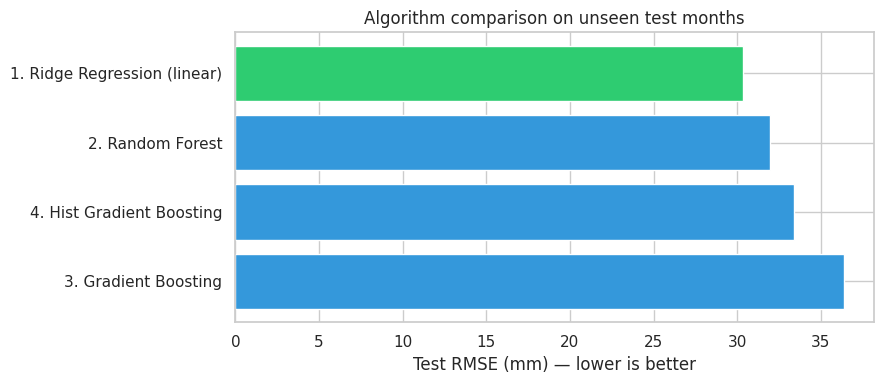

In [22]:
def compute_metrics(y_true, y_pred):
    """Return R2, RMSE, MAE for one model split."""
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": mean_absolute_error(y_true, y_pred),
    }


# Dictionary of 4 algorithms (default settings — fair first comparison)
candidate_models = {
    "1. Ridge Regression (linear)": Pipeline([
        ("scaler", StandardScaler()),  # Ridge needs similar scales for all columns
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    "2. Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "3. Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE
    ),
    "4. Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=6, random_state=RANDOM_STATE
    ),
}

comparison_rows = []
fitted_models = {}  # store trained models for optional plots

print("Training and evaluating each algorithm on the SAME train/test split...\n")
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    train_m = compute_metrics(y_train, pred_train)
    test_m = compute_metrics(y_test, pred_test)
    fitted_models[name] = model
    comparison_rows.append({
        "Algorithm": name,
        "Train_R2": train_m["R2"],
        "Test_R2": test_m["R2"],
        "Train_RMSE_mm": train_m["RMSE"],
        "Test_RMSE_mm": test_m["RMSE"],
        "Test_MAE_mm": test_m["MAE"],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Algorithm")
comparison_df = comparison_df.sort_values("Test_RMSE_mm")  # best = top row
comparison_df["Rank_by_Test_RMSE"] = range(1, len(comparison_df) + 1)

print("=== MODEL COMPARISON (sorted best → worst by Test RMSE) ===")
display(comparison_df.round(3))

# --- Select winner ---
SELECTED_MODEL_NAME = comparison_df.index[0]
selected_baseline = fitted_models[SELECTED_MODEL_NAME]
print(f"\n✓ SELECTED MODEL: {SELECTED_MODEL_NAME}")
print("  Reason: lowest Test RMSE on held-out recent months (primary rule).")

# Bar chart: compare Test RMSE across algorithms
plt.figure(figsize=(9, 4))
plot_order = comparison_df.sort_values("Test_RMSE_mm", ascending=True)
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(plot_order))]
plt.barh(plot_order.index, plot_order["Test_RMSE_mm"], color=colors)
plt.xlabel("Test RMSE (mm) — lower is better")
plt.title("Algorithm comparison on unseen test months")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# Overfitting gap: Train R2 minus Test R2 (large gap = memorizing training years)
comparison_df["Overfit_gap_R2"] = comparison_df["Train_R2"] - comparison_df["Test_R2"]
print("Overfitting check (Train R² − Test R²; smaller gap is safer):")
display(comparison_df[["Train_R2", "Test_R2", "Overfit_gap_R2"]].round(3))

Overfitting check (Train R² − Test R²; smaller gap is safer):


,Train_R2,Test_R2,Overfit_gap_R2
Algorithm,,,
1. Ridge Regression (linear),0.903,0.961,-0.058
2. Random Forest,0.986,0.957,0.028
4. Hist Gradient Boosting,0.967,0.953,0.014
3. Gradient Boosting,0.996,0.944,0.051


In [24]:
param_grids = {
    "1. Ridge Regression (linear)": {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "2. Random Forest": {
        "n_estimators": [200, 300],
        "max_depth": [10, 20, None],
        "min_samples_leaf": [1, 3],
    },
    "3. Gradient Boosting": {
        "n_estimators": [150, 250],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 5],
    },
    "4. Hist Gradient Boosting": {
        "max_iter": [200, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [4, 6, 8],
    },
}

tscv = TimeSeriesSplit(n_splits=3)
tuning_estimator = clone(candidate_models[SELECTED_MODEL_NAME])

print(f"Tuning: {SELECTED_MODEL_NAME} (may take 1–4 minutes)...")
grid_search = GridSearchCV(
    estimator=tuning_estimator,
    param_grid=param_grids[SELECTED_MODEL_NAME],
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("\n=== BEST HYPERPARAMETERS ===")
for key, val in grid_search.best_params_.items():
    print(f"  {key}: {val}")
print(f"\nCross-validation RMSE: {-grid_search.best_score_:.2f} mm")

Tuning: 1. Ridge Regression (linear) (may take 1–4 minutes)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

=== BEST HYPERPARAMETERS ===
  model__alpha: 1.0

Cross-validation RMSE: 48.71 mm


In [25]:
cv_results = pd.DataFrame(grid_search.cv_results_)
param_cols = [c for c in cv_results.columns if c.startswith("param_")]
top5 = cv_results.nsmallest(5, "rank_test_score")[param_cols + ["mean_test_score", "rank_test_score"]].copy()
top5["CV_RMSE_mm"] = (-top5["mean_test_score"]).round(2)
top5 = top5.drop(columns=["mean_test_score"])
print(f"Top 5 settings for {SELECTED_MODEL_NAME}:")
display(top5)

Top 5 settings for 1. Ridge Regression (linear):


,param_model__alpha,rank_test_score,CV_RMSE_mm
1,1.0,1,48.71
0,0.1,2,48.85
2,10.0,3,50.12
3,100.0,4,65.45


In [26]:
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)
print(f"Final model: {SELECTED_MODEL_NAME} (after hyperparameter tuning)")

# Predictions on train and test
y_pred_train = final_model.predict(X_train)
y_pred_test = final_model.predict(X_test)


def show_metrics(split_name, y_true, y_pred):
    """Print regression metrics with short explanations."""
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n--- {split_name} set ---")
    print(f"  R²   = {r2:.3f}  → fraction of rainfall variability explained (1.0 = perfect)")
    print(f"  RMSE = {rmse:.2f} mm → typical prediction error (penalizes large errors)")
    print(f"  MAE  = {mae:.2f} mm → average absolute error (easier to explain in reports)")
    return {"R2": r2, "RMSE": rmse, "MAE": mae}


train_metrics = show_metrics("TRAIN", y_train, y_pred_train)
test_metrics = show_metrics("TEST (unseen)", y_test, y_pred_test)

metrics_table = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
display(metrics_table.round(3))

# Compare tuned model vs same algorithm before tuning (Step 6 defaults)
baseline_pred = fitted_models[SELECTED_MODEL_NAME].predict(X_test)
baseline_rmse = float(np.sqrt(mean_squared_error(y_test, baseline_pred)))
tuned_rmse = test_metrics["RMSE"]
print(f"\n{SELECTED_MODEL_NAME} — Test RMSE before tuning: {baseline_rmse:.2f} mm")
print(f"{SELECTED_MODEL_NAME} — Test RMSE after tuning:  {tuned_rmse:.2f} mm")
if tuned_rmse < baseline_rmse:
    print("→ Tuning improved the model on the test period.")
else:
    print("→ Tuning did not beat defaults on test; defaults were already strong (report both).")

Final model: 1. Ridge Regression (linear) (after hyperparameter tuning)

--- TRAIN set ---
  R²   = 0.903  → fraction of rainfall variability explained (1.0 = perfect)
  RMSE = 49.95 mm → typical prediction error (penalizes large errors)
  MAE  = 28.47 mm → average absolute error (easier to explain in reports)

--- TEST (unseen) set ---
  R²   = 0.961  → fraction of rainfall variability explained (1.0 = perfect)
  RMSE = 30.35 mm → typical prediction error (penalizes large errors)
  MAE  = 19.75 mm → average absolute error (easier to explain in reports)


,R2,RMSE,MAE
Train,0.903,49.951,28.473
Test,0.961,30.347,19.752



1. Ridge Regression (linear) — Test RMSE before tuning: 30.35 mm
1. Ridge Regression (linear) — Test RMSE after tuning:  30.35 mm
→ Tuning did not beat defaults on test; defaults were already strong (report both).


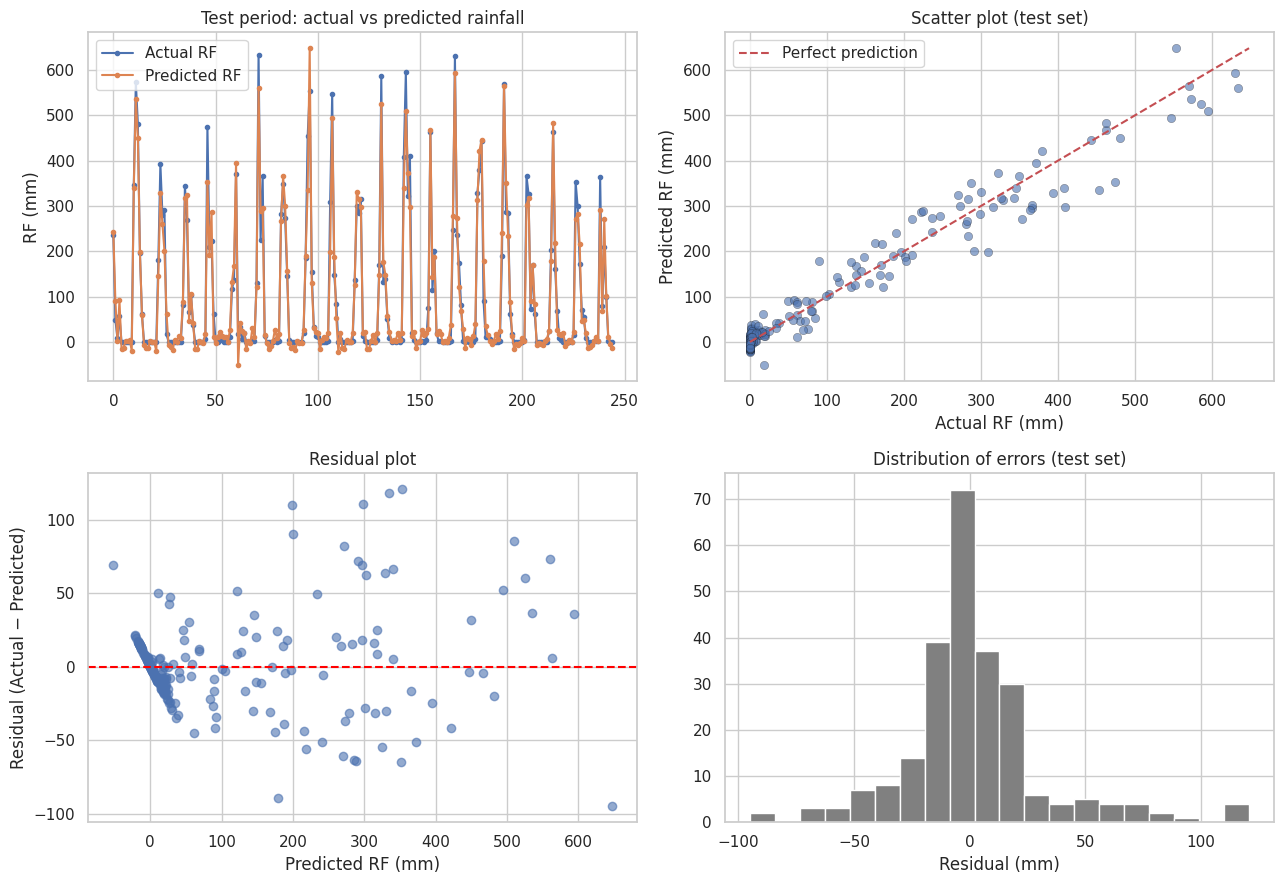

In [27]:
# --- Visual evaluation ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1) Actual vs predicted over test months
axes[0, 0].plot(y_test.values, label="Actual RF", marker="o", markersize=3)
axes[0, 0].plot(y_pred_test, label="Predicted RF", marker=".")
axes[0, 0].set_title("Test period: actual vs predicted rainfall")
axes[0, 0].set_ylabel("RF (mm)")
axes[0, 0].legend()

# 2) Scatter: points on red line = perfect prediction
axes[0, 1].scatter(y_test, y_pred_test, alpha=0.6, edgecolors="k", linewidths=0.3)
mx = max(y_test.max(), y_pred_test.max())
axes[0, 1].plot([0, mx], [0, mx], "r--", label="Perfect prediction")
axes[0, 1].set_xlabel("Actual RF (mm)")
axes[0, 1].set_ylabel("Predicted RF (mm)")
axes[0, 1].set_title("Scatter plot (test set)")
axes[0, 1].legend()

# 3) Residuals = actual - predicted (should scatter around 0)
residuals = y_test.values - y_pred_test
axes[1, 0].scatter(y_pred_test, residuals, alpha=0.6)
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("Predicted RF (mm)")
axes[1, 0].set_ylabel("Residual (Actual − Predicted)")
axes[1, 0].set_title("Residual plot")

# 4) Error distribution
axes[1, 1].hist(residuals, bins=20, color="gray", edgecolor="white")
axes[1, 1].set_xlabel("Residual (mm)")
axes[1, 1].set_title("Distribution of errors (test set)")

plt.tight_layout()
plt.show()

In [29]:
N_TOP_FEATURES = 9  # change to 3 if you want only three predictors in the formula


def rank_predictor_importance(model, X, y, feature_names):
    """
    Rank input columns by how much they drive predictions.
    Works for tree models, Ridge pipeline, etc.
    """
    # Tree-based models: built-in importance
    if hasattr(model, "feature_importances_"):
        scores = pd.Series(model.feature_importances_, index=feature_names)
        method = "feature_importances_ from winning model"
        return scores.sort_values(ascending=False), method

    # Ridge inside Pipeline (scaled inputs)
    if hasattr(model, "named_steps") and "model" in model.named_steps:
        coefs = np.abs(model.named_steps["model"].coef_)
        scores = pd.Series(coefs, index=feature_names)
        method = "absolute Ridge coefficients (after scaling in pipeline)"
        return scores.sort_values(ascending=False), method

    # Fallback: permutation importance (model-agnostic)
    perm = permutation_importance(
        model, X, y, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
    )
    scores = pd.Series(perm.importances_mean, index=feature_names)
    method = "permutation importance on training data"
    return scores.sort_values(ascending=False), method


importance_scores, importance_method = rank_predictor_importance(
    final_model, X_train, y_train, FEATURES
)

print(f"How importance was measured: {importance_method}")
print("\nAll predictors ranked (highest first):")
display(importance_scores.to_frame("importance").round(4))

top_features = importance_scores.head(N_TOP_FEATURES).index.tolist()
print(f"\nTop {N_TOP_FEATURES} columns used in the formula:", top_features)

How importance was measured: absolute Ridge coefficients (after scaling in pipeline)

All predictors ranked (highest first):


,importance
WDF,219.1097
CC,54.3653
RCETO,22.5863
ATE,20.5418
MTE,9.7835
DTR,5.5895
month_num,3.7243
VP,2.3739
Year,0.1063



Top 9 columns used in the formula: ['WDF', 'CC', 'RCETO', 'ATE', 'MTE', 'DTR', 'month_num', 'VP', 'Year']


In [30]:
# Fit a simple linear model: RF = intercept + sum(coef_i * column_i)
# Trained on TRAIN data only, using raw column values (no scaling → direct formula)
formula_model = LinearRegression()
formula_model.fit(X_train[top_features], y_train)

intercept = formula_model.intercept_
coefficients = pd.Series(formula_model.coef_, index=top_features)

# --- Plain-English / report formula ---
def build_formula_string(target, coef_series, b0):
    parts = [f"{b0:.4f}"]
    for name, coef in coef_series.items():
        sign = "+" if coef >= 0 else "-"
        parts.append(f" {sign} {abs(coef):.4f}×{name}")
    return f"{target} = " + "".join(parts)


formula_plain = build_formula_string(TARGET, coefficients, intercept)
print("=" * 70)
print("RAINFALL FORMULA (linear, top predictors only)")
print("=" * 70)
print(formula_plain)
print("\nCopy the line above into your report / thesis.")

# --- LaTeX version for Word / LaTeX reports ---
latex_terms = [f"{intercept:.4f}"]
for name, coef in coefficients.items():
    sign = "+" if coef >= 0 else "-"
    safe_name = name.replace("_", "\\_")
    latex_terms.append(f" {sign} {abs(coef):.4f}\\cdot \\mathrm{{{safe_name}}}")
formula_latex = "RF = " + "".join(latex_terms)
print("\nLaTeX form:")
print(formula_latex)

# Coefficient table with meaning
coef_table = pd.DataFrame({
    "Variable": top_features,
    "Coefficient (β)": coefficients.values,
    "Meaning": [
        f"If {f} increases by 1 unit, RF changes by {coefficients[f]:+.3f} mm (others fixed)"
        for f in top_features
    ],
})
coef_table.loc[len(coef_table)] = {
    "Variable": "Intercept (β₀)",
    "Coefficient (β)": intercept,
    "Meaning": "Predicted RF when all top predictors are zero (reference baseline)",
}
display(coef_table)

RAINFALL FORMULA (linear, top predictors only)
RF = -75.5053 + 46.3084×WDF - 2.5940×CC + 41.8379×RCETO - 398.4178×ATE + 392.6937×MTE - 191.3204×DTR + 1.8133×month_num - 1.5937×VP + 0.0009×Year

Copy the line above into your report / thesis.

LaTeX form:
RF = -75.5053 + 46.3084\cdot \mathrm{WDF} - 2.5940\cdot \mathrm{CC} + 41.8379\cdot \mathrm{RCETO} - 398.4178\cdot \mathrm{ATE} + 392.6937\cdot \mathrm{MTE} - 191.3204\cdot \mathrm{DTR} + 1.8133\cdot \mathrm{month\_num} - 1.5937\cdot \mathrm{VP} + 0.0009\cdot \mathrm{Year}


,Variable,Coefficient (β),Meaning
0,WDF,46.308424,"If WDF increases by 1 unit, RF changes by +46...."
1,CC,-2.594012,"If CC increases by 1 unit, RF changes by -2.59..."
2,RCETO,41.837875,"If RCETO increases by 1 unit, RF changes by +4..."
3,ATE,-398.417846,"If ATE increases by 1 unit, RF changes by -398..."
4,MTE,392.693676,"If MTE increases by 1 unit, RF changes by +392..."
5,DTR,-191.320402,"If DTR increases by 1 unit, RF changes by -191..."
6,month_num,1.813274,"If month_num increases by 1 unit, RF changes b..."
7,VP,-1.593721,"If VP increases by 1 unit, RF changes by -1.59..."
8,Year,0.000942,"If Year increases by 1 unit, RF changes by +0...."
9,Intercept (β₀),-75.505333,Predicted RF when all top predictors are zero ...


In [31]:
all_formula_results = []

for n_features in range(9, 3, -1):
    print(f"\n{'='*70}\nGenerating formula for Top {n_features} Predictors\n{'='*70}")

    current_n_top_features = n_features

    importance_scores, importance_method = rank_predictor_importance(
        final_model, X_train, y_train, FEATURES
    )
    top_features = importance_scores.head(current_n_top_features).index.tolist()

    print(f"\nTop {current_n_top_features} columns used in the formula:", top_features)

    formula_model = LinearRegression()
    formula_model.fit(X_train[top_features], y_train)

    intercept = formula_model.intercept_
    coefficients = pd.Series(formula_model.coef_, index=top_features)

    formula_plain = build_formula_string(TARGET, coefficients, intercept)
    print("\n" + "=" * 70)
    print(f"RAINFALL FORMULA (linear, top {current_n_top_features} predictors only)")
    print("=" * 70)
    print(formula_plain)
    print("\nCopy the line above into your report / thesis.")

    latex_terms = [f"{intercept:.4f}"]
    for name, coef in coefficients.items():
        sign = "+" if coef >= 0 else "-"
        safe_name = name.replace("_", "\\")
        latex_terms.append(f" {sign} {abs(coef):.4f}\\cdot \\mathrm{{{safe_name}}}")
    formula_latex = "RF = " + "".join(latex_terms)
    print("\nLaTeX form:")
    print(formula_latex)

    y_formula_train = formula_model.predict(X_train[top_features])
    y_formula_test = formula_model.predict(X_test[top_features])

    metrics_data = {
        "Split_Train_R2": r2_score(y_train, y_formula_train),
        "Split_Train_RMSE_mm": np.sqrt(mean_squared_error(y_train, y_formula_train)),
        "Split_Test_R2": r2_score(y_test, y_formula_test),
        "Split_Test_RMSE_mm": np.sqrt(mean_squared_error(y_test, y_formula_test)),
    }
    metrics_df = pd.DataFrame([{
        "Split": "Train", "R2": metrics_data["Split_Train_R2"], "RMSE_mm": metrics_data["Split_Train_RMSE_mm"]
    }, {
        "Split": "Test", "R2": metrics_data["Split_Test_R2"], "RMSE_mm": metrics_data["Split_Test_RMSE_mm"]
    }])
    print(f"\nMetrics for the linear formula with {current_n_top_features} predictors:")
    display(metrics_df.round(3))

    coef_table = pd.DataFrame({
        "Variable": top_features,
        "Coefficient (β)": coefficients.values,
        "Meaning": [
            f"If {f} increases by 1 unit, RF changes by {coefficients[f]:+.3f} mm (others fixed)"
            for f in top_features
        ],
    })
    coef_table.loc[len(coef_table)] = {
        "Variable": "Intercept (β₀)",
        "Coefficient (β)": intercept,
        "Meaning": "Predicted RF when all top predictors are zero (reference baseline)",
    }
    print("\nCoefficient Table:")
    display(coef_table)

    all_formula_results.append({
        "n_features": current_n_top_features,
        "top_features": top_features,
        "intercept": intercept,
        "coefficients": coefficients.to_dict(),
        "formula_plain": formula_plain,
        "formula_latex": formula_latex,
        "metrics": metrics_data
    })

# --- Determine the best simplified formula ---
if all_formula_results:
    best_formula_result = min(all_formula_results, key=lambda x: x["metrics"]["Split_Test_RMSE_mm"])

    print(f"\n{'='*70}\nBEST SIMPLIFIED FORMULA (based on lowest Test RMSE)\n{'='*70}")
    print(f"Number of predictors: {best_formula_result['n_features']}")
    print(f"Top features: {best_formula_result['top_features']}")
    print(f"\nPlain Formula:\n{best_formula_result['formula_plain']}")
    print(f"\nLaTeX Formula:\n{best_formula_result['formula_latex']}")

    # Reconstruct coefficient table for the best formula for display
    best_coef_table = pd.DataFrame({
        "Variable": best_formula_result['top_features'],
        "Coefficient (β)": list(best_formula_result['coefficients'].values()),
        "Meaning": [
            f"If {f} increases by 1 unit, RF changes by {best_formula_result['coefficients'][f]:+.3f} mm (others fixed)"
            for f in best_formula_result['top_features']
        ],
    })
    best_coef_table.loc[len(best_coef_table)] = {
        "Variable": "Intercept (β₀)",
        "Coefficient (β)": best_formula_result['intercept'],
        "Meaning": "Predicted RF when all top predictors are zero (reference baseline)",
    }
    print("\nCoefficient Table for Best Simplified Formula:")
    display(best_coef_table)

    # Display metrics for the best simplified formula
    best_metrics_df = pd.DataFrame([{
        "Split": "Train", "R2": best_formula_result["metrics"]["Split_Train_R2"], "RMSE_mm": best_formula_result["metrics"]["Split_Train_RMSE_mm"]
    }, {
        "Split": "Test", "R2": best_formula_result["metrics"]["Split_Test_R2"], "RMSE_mm": best_formula_result["metrics"]["Split_Test_RMSE_mm"]
    }])
    print("\nMetrics for Best Simplified Formula:")
    display(best_metrics_df.round(3))
else:
    print("No formula results were generated.")


Generating formula for Top 9 Predictors

Top 9 columns used in the formula: ['WDF', 'CC', 'RCETO', 'ATE', 'MTE', 'DTR', 'month_num', 'VP', 'Year']

RAINFALL FORMULA (linear, top 9 predictors only)
RF = -75.5053 + 46.3084×WDF - 2.5940×CC + 41.8379×RCETO - 398.4178×ATE + 392.6937×MTE - 191.3204×DTR + 1.8133×month_num - 1.5937×VP + 0.0009×Year

Copy the line above into your report / thesis.

LaTeX form:
RF = -75.5053 + 46.3084\cdot \mathrm{WDF} - 2.5940\cdot \mathrm{CC} + 41.8379\cdot \mathrm{RCETO} - 398.4178\cdot \mathrm{ATE} + 392.6937\cdot \mathrm{MTE} - 191.3204\cdot \mathrm{DTR} + 1.8133\cdot \mathrm{month\num} - 1.5937\cdot \mathrm{VP} + 0.0009\cdot \mathrm{Year}

Metrics for the linear formula with 9 predictors:


,Split,R2,RMSE_mm
0,Train,0.904,49.717
1,Test,0.963,29.820



Coefficient Table:


,Variable,Coefficient (β),Meaning
0,WDF,46.308424,"If WDF increases by 1 unit, RF changes by +46...."
1,CC,-2.594012,"If CC increases by 1 unit, RF changes by -2.59..."
2,RCETO,41.837875,"If RCETO increases by 1 unit, RF changes by +4..."
3,ATE,-398.417846,"If ATE increases by 1 unit, RF changes by -398..."
4,MTE,392.693676,"If MTE increases by 1 unit, RF changes by +392..."
5,DTR,-191.320402,"If DTR increases by 1 unit, RF changes by -191..."
6,month_num,1.813274,"If month_num increases by 1 unit, RF changes b..."
7,VP,-1.593721,"If VP increases by 1 unit, RF changes by -1.59..."
8,Year,0.000942,"If Year increases by 1 unit, RF changes by +0...."
9,Intercept (β₀),-75.505333,Predicted RF when all top predictors are zero ...



Generating formula for Top 8 Predictors

Top 8 columns used in the formula: ['WDF', 'CC', 'RCETO', 'ATE', 'MTE', 'DTR', 'month_num', 'VP']

RAINFALL FORMULA (linear, top 8 predictors only)
RF = -73.7911 + 46.3090×WDF - 2.5939×CC + 41.8213×RCETO - 398.3643×ATE + 392.6463×MTE - 191.2922×DTR + 1.8125×month_num - 1.5932×VP

Copy the line above into your report / thesis.

LaTeX form:
RF = -73.7911 + 46.3090\cdot \mathrm{WDF} - 2.5939\cdot \mathrm{CC} + 41.8213\cdot \mathrm{RCETO} - 398.3643\cdot \mathrm{ATE} + 392.6463\cdot \mathrm{MTE} - 191.2922\cdot \mathrm{DTR} + 1.8125\cdot \mathrm{month\num} - 1.5932\cdot \mathrm{VP}

Metrics for the linear formula with 8 predictors:


...

,Variable,Coefficient (β),Meaning
0,WDF,46.208392,"If WDF increases by 1 unit, RF changes by +46...."
1,CC,-3.808918,"If CC increases by 1 unit, RF changes by -3.80..."
2,RCETO,28.730804,"If RCETO increases by 1 unit, RF changes by +2..."
3,ATE,-4.301282,"If ATE increases by 1 unit, RF changes by -4.3..."
4,Intercept (β₀),15.022726,Predicted RF when all top predictors are zero ...



BEST SIMPLIFIED FORMULA (based on lowest Test RMSE)
Number of predictors: 7
Top features: ['WDF', 'CC', 'RCETO', 'ATE', 'MTE', 'DTR', 'month_num']

Plain Formula:
RF = -107.4959 + 46.2383×WDF - 2.6753×CC + 38.4611×RCETO - 340.6406×ATE + 335.0712×MTE - 160.3928×DTR + 1.8022×month_num

LaTeX Formula:
RF = -107.4959 + 46.2383\cdot \mathrm{WDF} - 2.6753\cdot \mathrm{CC} + 38.4611\cdot \mathrm{RCETO} - 340.6406\cdot \mathrm{ATE} + 335.0712\cdot \mathrm{MTE} - 160.3928\cdot \mathrm{DTR} + 1.8022\cdot \mathrm{month\num}

Coefficient Table for Best Simplified Formula:


,Variable,Coefficient (β),Meaning
0,WDF,46.238278,"If WDF increases by 1 unit, RF changes by +46...."
1,CC,-2.675310,"If CC increases by 1 unit, RF changes by -2.67..."
2,RCETO,38.461071,"If RCETO increases by 1 unit, RF changes by +3..."
3,ATE,-340.640610,"If ATE increases by 1 unit, RF changes by -340..."
4,MTE,335.071214,"If MTE increases by 1 unit, RF changes by +335..."
5,DTR,-160.392761,"If DTR increases by 1 unit, RF changes by -160..."
6,month_num,1.802169,"If month_num increases by 1 unit, RF changes b..."
7,Intercept (β₀),-107.495938,Predicted RF when all top predictors are zero ...



Metrics for Best Simplified Formula:


,Split,R2,RMSE_mm
0,Train,0.904,49.767
1,Test,0.963,29.498
